In [ ]:
# 1. IMPORT LIBRARIES

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# 2. LOAD DATA FROM KAGGLE FOLDER STRUCTURE

In [3]:
DATA_DIR = "20news-bydate"

documents = []
labels = []
target_names = []

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Could not find directory: {DATA_DIR}")

In [13]:
documents = []
labels = []
target_names = [] 

# Now your existing loop runs cleanly...
print("Parsing combined text files...")
for class_idx, filename in enumerate(file_list):
    category_name = filename.replace('.txt', '')
    target_names.append(category_name)

Parsing combined text files...


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training elements: {len(X_train)} | Testing elements: {len(X_test)}")

Training elements: 94324 | Testing elements: 23582


In [15]:
# 3. BUILD AND TRAIN THE MULTI-CLASS ML PIPELINE

In [19]:
def aggressive_clean(text):
    # Remove standard automated reply headers
    text = re.sub(r'In article <.*?>|writes:|tmg@|archive', '', text, flags=re.IGNORECASE)
    
    # Remove email addresses completely
    text = re.sub(r'\S+@\S+', '', text)
    
    # Keep only pure letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    return text.lower()

# Apply to your data list
X_clean = [aggressive_clean(doc) for doc in X]

In [20]:
document_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(stop_words='english', sublinear_tf=True, min_df=2, max_features=10000)),
    ('classifier', LinearSVC(random_state=42, C=1.0, class_weight='balanced'))
])

print("Training the LinearSVC Pipeline on your 20 categories...")
document_pipeline.fit(X_train, y_train)
print("🎯 Model trained successfully!")

Training the LinearSVC Pipeline on your 20 categories...
🎯 Model trained successfully!


In [ ]:
# 4. Evaluation

In [21]:
predictions = document_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Overall Document Classification Accuracy: {accuracy * 100:.2f}%\n")
clean_target_names = sorted(list(set(target_names)))

print("Detailed Classification Report:")
print(classification_report(y_test, predictions, target_names=clean_target_names))

Overall Document Classification Accuracy: 99.92%

Detailed Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       1.00      1.00      1.00      1445
           comp.graphics       1.00      1.00      1.00      1501
 comp.os.ms-windows.misc       1.00      1.00      1.00      1191
comp.sys.ibm.pc.hardware       1.00      1.00      1.00      1196
   comp.sys.mac.hardware       1.00      1.00      1.00      1159
          comp.windows.x       1.00      1.00      1.00      1186
            misc.forsale       1.00      1.00      1.00      1173
               rec.autos       1.00      1.00      1.00      1195
         rec.motorcycles       1.00      1.00      1.00      1196
      rec.sport.baseball       1.00      1.00      1.00      1196
        rec.sport.hockey       1.00      1.00      1.00      1202
               sci.crypt       1.00      1.00      1.00      1205
         sci.electronics       1.00      1.00      1.00    

In [ ]:
# 5. Visualization of the Confusion matrix

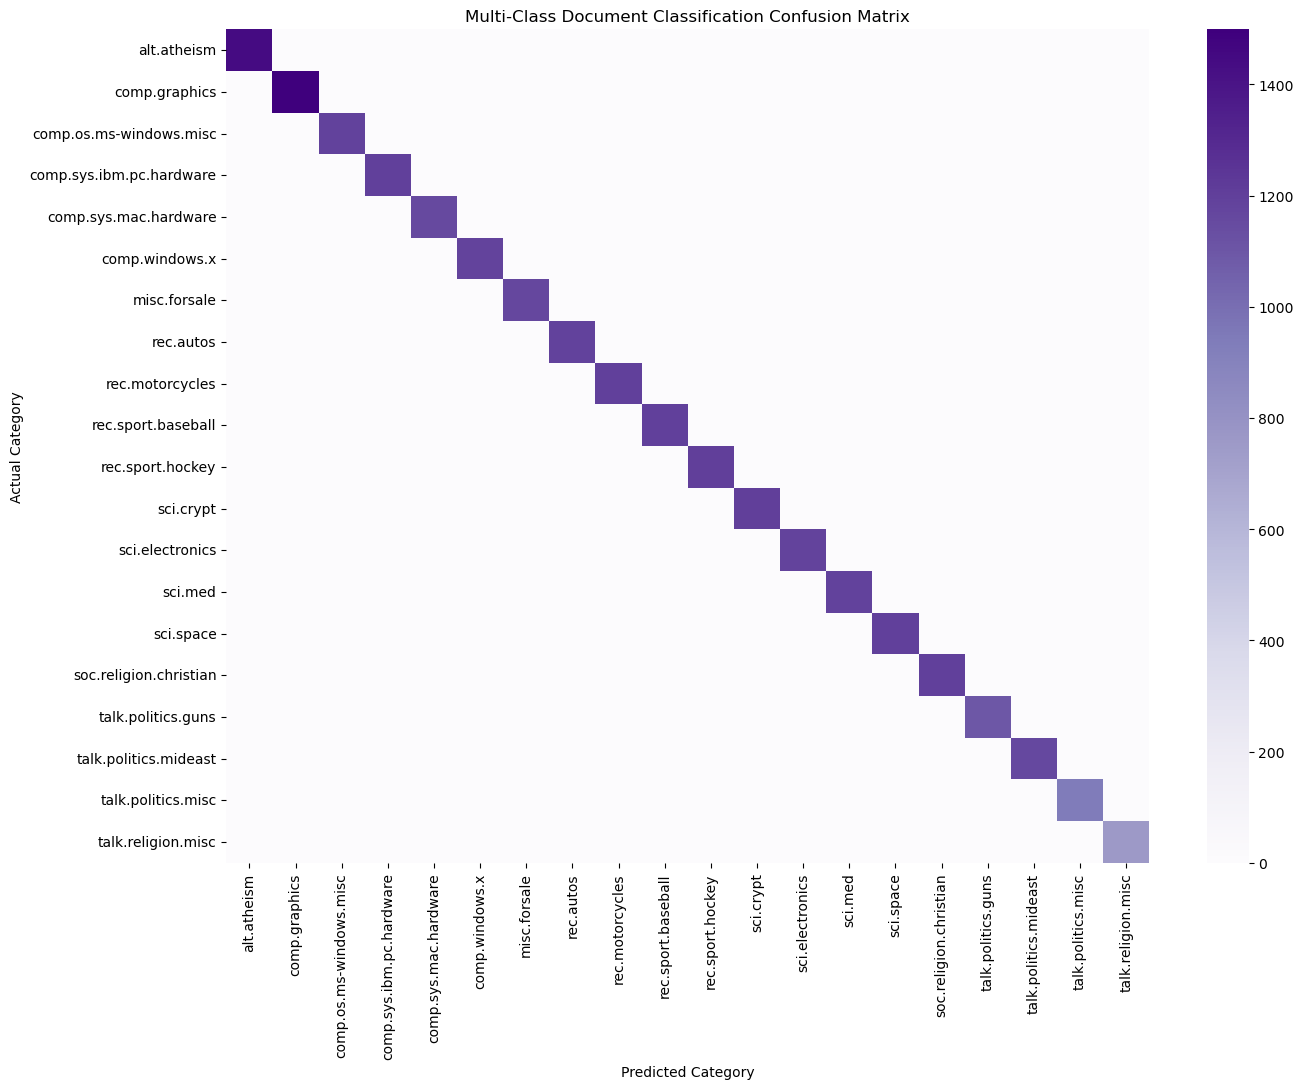

In [22]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm, 
    annot=False, # Set to True if you want numbers inside squares, but with 20 classes it can look crowded
    cmap='Purples', 
    xticklabels=target_names, 
    yticklabels=target_names
)

plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('Multi-Class Document Classification Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 6. Model File Saved

In [23]:
import joblib

model_filename = 'multiclass_document_classifier.pkl'
joblib.dump(document_pipeline, model_filename)

print(f"💾 Multi-class pipeline successfully saved as: {model_filename}")

💾 Multi-class pipeline successfully saved as: multiclass_document_classifier.pkl
